In [1]:
import os
os.chdir("/Users/srujansingh/Documents/JeanFan_Lab/Kidney_Structural_Analysis/")

In [2]:
import scanpy as sc
#ctrl1_data only contains the all the tubule annotations:
ctrl1_data = sc.read_h5ad("data/2um/Ctrl_1A2/Ctrl_1A2_visiumhd_2um_proximal_labeled.h5ad")
ctrl1_data.obs.shape

(5549563, 6)

In [3]:
#Subset the AnnData to only contain proximal tubules
ctrl1_A2_PT=ctrl1_data[~ctrl1_data.obs['proximal_tubule_geojson_feature_index'].isna()]
ctrl1_A2_PT.shape #to check the dimensions of the subset matrix.
ctrl1_A2_PT.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index
s_002um_00304_00021-1,1,304,21,2407.153091,18011.820723,929
s_002um_00304_00022-1,1,304,22,2407.205739,18007.281833,929
s_002um_00304_00023-1,1,304,23,2407.258388,18002.742943,929
s_002um_00304_00024-1,1,304,24,2407.311036,17998.204053,929
s_002um_00304_00025-1,1,304,25,2407.363684,17993.665163,929
...,...,...,...,...,...,...
s_002um_03081_00927-1,1,3081,927,15050.493122,14042.298862,5938
s_002um_03081_00928-1,1,3081,928,15050.545696,14037.759889,5938
s_002um_03081_00929-1,1,3081,929,15050.598270,14033.220917,5938
s_002um_03081_00930-1,1,3081,930,15050.650844,14028.681944,5938


CONVERT THE BINS IN A PROXIMAL TUBULE TO A DISTANCE MAP (FOR A SINGLE MAP)

In [4]:
#Importing the geojson files which contains the proximal tubule annotations and boudary information.
import geopandas as gpd
gdf=gpd.read_file("data/2um/geojson/Ctrl_1A2_tubules_processed_caleb.geojson")

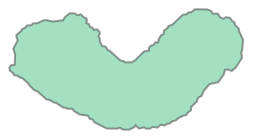

In [5]:
#Extracting geometrical information for a particular PT (let's ID=929 on the geojson file)
tubule=gdf[gdf["id"]=="929"]
geom=tubule.geometry.iloc[0]
geom

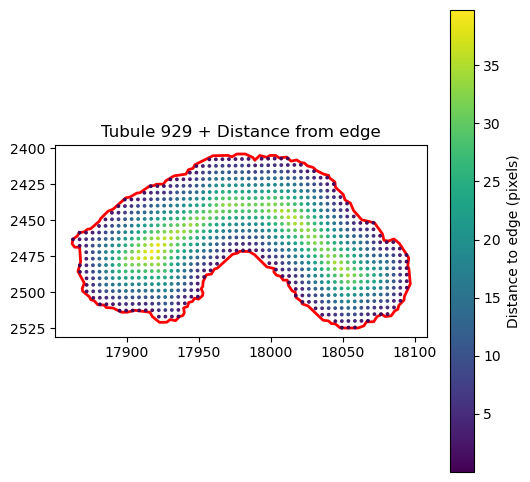

In [ ]:
#Extract corresponding bin coordinates:
subset = ctrl1_A2_PT[ctrl1_A2_PT.obs['proximal_tubule_geojson_feature_index'].astype(str) == "929"].copy() #subset contains only 929 PT 2um bins.

x = subset.obs["pxl_col_in_fullres"]
y = subset.obs["pxl_row_in_fullres"]

#Convert bins to shapely points:
from shapely.geometry import Point
points = [Point(xy) for xy in zip(x, y)]

#Extract the polygon boundary:
boundary = geom.boundary

#Computing distance to edge:
distances = [p.distance(boundary) for p in points]

#Append this new distance matrix into the subset data:
subset.obs["dist_to_edge"] = distances

#Plot/Overlay
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,6))

# plotting the polygon (from the geojson file)
gdf[gdf["id"] == "929"].plot(ax=ax, color="none", edgecolor="red", linewidth=2)

# plot the Visium HD bins scatter 
sc = ax.scatter(
    subset.obs["pxl_col_in_fullres"].values,
    subset.obs["pxl_row_in_fullres"].values,
    c=subset.obs["dist_to_edge"].values,
    s=3,
    cmap="viridis"
)

# attach colorbar to SAME figure
fig.colorbar(sc, ax=ax, label="Distance to edge (pixels)")

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title("Tubule 929 + Distance from edge")

plt.show()

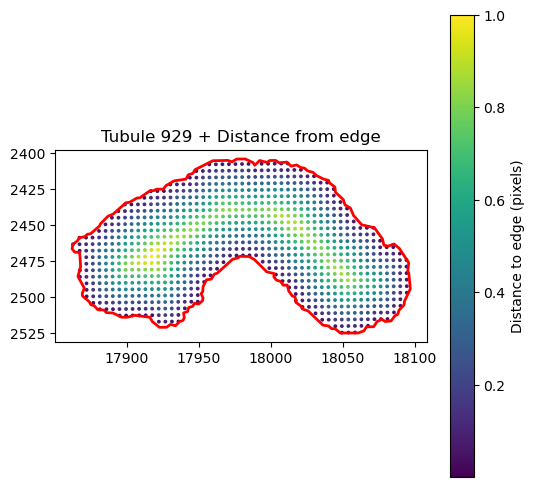

In [ ]:
#Plot in the format of a radial distance:
# plot the Visium HD bins scatter 
fig, ax = plt.subplots(figsize=(6,6))
sc = ax.scatter(
    subset.obs["pxl_col_in_fullres"].values,
    subset.obs["pxl_row_in_fullres"].values,
    c=subset.obs["dist_to_edge"].values/max(subset.obs["dist_to_edge"].values),
    s=3,
    cmap="viridis"
)
# plotting the polygon (from the geojson file)
gdf[gdf["id"] == "929"].plot(ax=ax, color="none", edgecolor="red", linewidth=2)

# attach colorbar to SAME figure
fig.colorbar(sc, ax=ax, label="Distance to edge (Non Dimensional)")

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title("Tubule 929 + Distance from edge")

plt.show()

In [13]:
#appending the distance values to the subset matrix:
subset.obs["Dist_Edge"]=subset.obs["dist_to_edge"].values/max(subset.obs["dist_to_edge"].values)
subset.obs.shape

(868, 8)

In [14]:
subset.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index,dist_to_edge,Dist_Edge
s_002um_00304_00021-1,1,304,21,2407.153091,18011.820723,929,0.205160,0.005161
s_002um_00304_00022-1,1,304,22,2407.205739,18007.281833,929,0.608511,0.015308
s_002um_00304_00023-1,1,304,23,2407.258388,18002.742943,929,2.188251,0.055047
s_002um_00304_00024-1,1,304,24,2407.311036,17998.204053,929,1.176446,0.029594
s_002um_00304_00025-1,1,304,25,2407.363684,17993.665163,929,1.881598,0.047333
...,...,...,...,...,...,...,...,...
s_002um_00329_00013-1,1,329,13,2520.121786,18049.417465,929,4.384319,0.110291
s_002um_00329_00014-1,1,329,14,2520.174434,18044.878574,929,1.829413,0.046020
s_002um_00330_00011-1,1,330,11,2524.552087,18058.546674,929,0.363228,0.009137
s_002um_00330_00012-1,1,330,12,2524.604735,18054.007782,929,0.321633,0.008091


In [16]:
import pandas as pd
import numpy as np

# Define bins
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

subset.obs["dist_bin"] = pd.cut(
    subset.obs["Dist_Edge"],
    bins=bins,
    labels=False,
    include_lowest=True
)
subset.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index,dist_to_edge,Dist_Edge,dist_bin
s_002um_00304_00021-1,1,304,21,2407.153091,18011.820723,929,0.205160,0.005161,0
s_002um_00304_00022-1,1,304,22,2407.205739,18007.281833,929,0.608511,0.015308,0
s_002um_00304_00023-1,1,304,23,2407.258388,18002.742943,929,2.188251,0.055047,0
s_002um_00304_00024-1,1,304,24,2407.311036,17998.204053,929,1.176446,0.029594,0
s_002um_00304_00025-1,1,304,25,2407.363684,17993.665163,929,1.881598,0.047333,0
...,...,...,...,...,...,...,...,...,...
s_002um_00329_00013-1,1,329,13,2520.121786,18049.417465,929,4.384319,0.110291,0
s_002um_00329_00014-1,1,329,14,2520.174434,18044.878574,929,1.829413,0.046020,0
s_002um_00330_00011-1,1,330,11,2524.552087,18058.546674,929,0.363228,0.009137,0
s_002um_00330_00012-1,1,330,12,2524.604735,18054.007782,929,0.321633,0.008091,0


In [17]:
bin_means = []
bin_centers = []

for b in range(5):
    mask = subset.obs["dist_bin"] == b
    
    if np.sum(mask) == 0:
        continue
    
    X_bin = subset[mask].X
    
    mean_expr = X_bin.mean(axis=0)
    bin_means.append(np.array(mean_expr).flatten())
    
    # use mean distance of that bin
    bin_centers.append(subset.obs.loc[mask, "Dist_Edge"].mean())

bin_means = np.vstack(bin_means)
bin_centers = np.array(bin_centers).reshape(-1, 1)

In [19]:
betas = []

from sklearn.linear_model import LinearRegression
for g in range(bin_means.shape[1]):
    y = bin_means[:, g]
    
    model = LinearRegression().fit(bin_centers, y)
    betas.append(model.coef_[0])

Edge genes:
 ['Gpx3', 'mt-Co2', 'Igfbp7', 'Selenop', 'Acsm2', 'Kap', 'Ass1', 'Slc34a1', 'Timp3', 'Tcn2', 'Itm2b', 'Slc5a2', 'Gpx1', 'mt-Co1', 'Pck1', 'mt-Nd4l', 'mt-Atp6', 'Maf', 'Cltrn', 'Slc27a2', 'Aldh4a1', 'Ptms', 'Ndrg1', 'Cd63', 'Akr1a1', 'Dab2', 'mt-Atp8', 'Dnase1', 'Alpl', 'Atp6v1g1', 'mt-Cytb', 'Akr1c21', 'Miox', 'Lrpap1', 'Aldob', 'Eef1a1', 'Fxyd2', 'Spink1', 'Lgmn', 'Rbm47', 'Chpt1', 'Tpt1', 'Hadh', 'mt-Nd5', 'Sult1d1', 'Aldh6a1', 'Atp1a1', 'Apoe', 'Pah', 'mt-Nd1', 'Keg1', 'Oxct1', 'Mdh1', 'Lrp2', 'Kcnj16', 'Prodh', 'Atp6v0a4', 'Atp1b1', 'Tmem176a', 'Sdhc', 'Acy3', 'Psap', 'Sord', 'Slc7a7', 'Galnt11', 'Idh2', 'Uqcrc1', 'Ccdc107', 'Enpp2', 'Tnfaip8', 'Cyb5a', 'Ndufa3', 'Pdzk1ip1', 'Slc5a12', 'App', 'Lamp2', 'Sephs2', 'Ubc', 'Nap1l4', 'Guca2b', 'Atp5o', 'Aldh7a1', 'Igfbp5', 'Id2', 'Tax1bp1', 'Kif12', 'Ak3', 'Sod3', 'Hnf4a', 'Ube2r2', 'Ldhb', 'Gcnt1', 'Camk2n1', 'mt-Nd4', 'Etfb', 'Gadd45g', 'Chchd10', 'Dgcr6', 'Vcp', 'Tef']

Center genes:
 ['Prdx5', 'Pipox', 'Aspscr1', 'Ryk', '

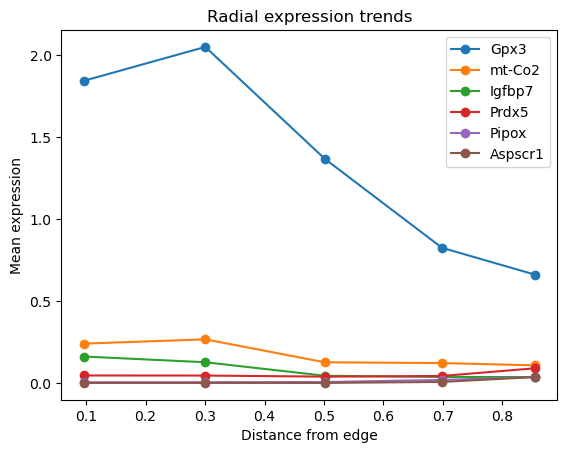

In [ ]:
subset.var["dist_slope"] = betas

top_edge = subset.var.sort_values("dist_slope").head(20) #Only selecting the the top 20 genes
top_center = subset.var.sort_values("dist_slope", ascending=False).head(20)

print("Edge genes:\n", top_edge.index.tolist())
print("\nCenter genes:\n", top_center.index.tolist())

import matplotlib.pyplot as plt

genes_to_plot = top_edge.index[:3].tolist() + top_center.index[:3].tolist()

for gene in genes_to_plot:
    g_idx = subset.var_names.get_loc(gene)
    
    plt.plot(bin_centers, bin_means[:, g_idx], marker='o', label=gene)

plt.xlabel("Distance from edge")
plt.ylabel("Mean expression")
plt.title("Radial expression trends")
plt.legend()
plt.show()

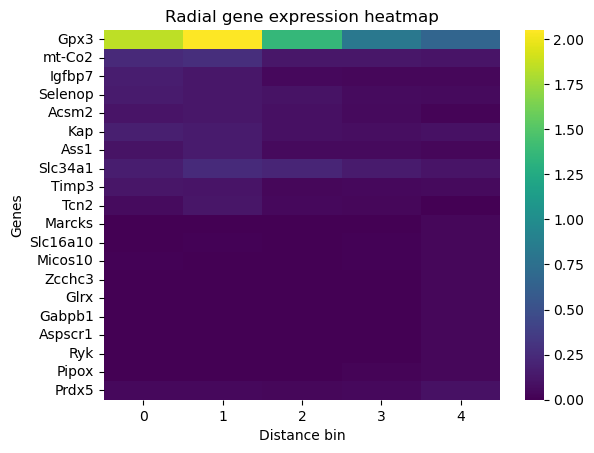

In [22]:
import seaborn as sns

# sort genes by slope
order = np.argsort(betas)

# take top varying genes (avoid plotting all 18k)
top_idx = np.concatenate([order[:10], order[-10:]])

data = bin_means[:, top_idx]

sns.heatmap(data.T, cmap="viridis",
            yticklabels=subset.var_names[top_idx])

plt.xlabel("Distance bin")
plt.ylabel("Genes")
plt.title("Radial gene expression heatmap")
plt.show()

In [30]:
subset.var.loc["Gpx3", "dist_slope"]

np.float64(-1.8709629788193873)